## Visualización inicial de los Datos

In [11]:
import pandas as pd

# Cargar el dataset
df = pd.read_csv('Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv')

# 1. Ver las columnas disponibles
print("=== COLUMNAS DEL DATASET ===")
print(df.columns.tolist())

# 2. Ver la forma del dataset (filas, columnas)
print(f"\nEl dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# 3. Mostrar las primeras 3 filas para entender el contenido
display(df.head(3))

=== COLUMNAS DEL DATASET ===
['flags', 'instruction', 'category', 'intent', 'response']

El dataset tiene 26872 filas y 5 columnas.


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


## 1. Selección de Características (Nuevo Dataset Bitext)

Se utilizará un nuevo dataset. Para el entrenamiento del modelo Naïve Bayes, nos enfocaremos en la variable objetivo original (`intent`) y en el texto ingresado por el usuario (`instruction`).

In [12]:
import pandas as pd

# Asumiendo que ya cargaste el nuevo dataset en 'df'
# df = pd.read_csv('nombre_de_tu_nuevo_archivo.csv')

# 1. Crear un dataframe reducido solo con lo que necesitamos
df_model = df[['intent', 'instruction']].copy()

# 2. Renombrar columnas para mantener la compatibilidad con el resto de tu Notebook
df_model.rename(columns={'instruction': 'Full_Text', 'intent': 'Ticket_Type_Original'}, inplace=True)

# 3. Mostrar las intenciones (intents) disponibles para hacer el nuevo mapeo
print("=== DISTRIBUCIÓN ORIGINAL DE INTENTS (TOP 20) ===")
print(df_model['Ticket_Type_Original'].value_counts().head(20))

=== DISTRIBUCIÓN ORIGINAL DE INTENTS (TOP 20) ===
Ticket_Type_Original
check_invoice               1000
complaint                   1000
contact_customer_service    1000
edit_account                1000
switch_account              1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
payment_issue                999
registration_problems        999
cancel_order                 998
place_order                  998
track_refund                 998
change_order                 997
check_refund_policy          997
create_account               997
get_refund                   997
review                       997
Name: count, dtype: int64


## 2. Preprocesamiento de Texto (NLP Pipeline)

Se aplica el pipeline de preprocesamiento utilizando `nltk`. Dado que este es un dataset con lenguaje natural real, se utilizarán únicamente las stopwords estándar del idioma inglés.

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Volvemos a las stopwords normales (sin el parche de palabras repetidas)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(texto):
    texto = str(texto).lower()
    # Esta expresión regular limpiará automáticamente los corchetes como {{Order Number}}
    texto = re.sub(r'[^a-z\s]', '', texto)
    tokens = word_tokenize(texto)
    tokens_procesados = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens_procesados)

df_model['Clean_Text'] = df_model['Full_Text'].apply(clean_and_tokenize)

print("\n=== RESULTADO DEL PREPROCESAMIENTO ===")
print("Original:", df_model['Full_Text'].iloc[0][:100], "...")
print("Procesado:", df_model['Clean_Text'].iloc[0][:100], "...")


=== RESULTADO DEL PREPROCESAMIENTO ===
Original: question about cancelling order {{Order Number}} ...
Procesado: question cancelling order order number ...


## 3. Mapeo y Agrupación de Categorías

El dataset de Bitext proporciona intenciones (intents) granulares. Para cumplir con la rúbrica del proyecto, se agrupan estas intenciones específicas en las 5 macro-categorías requeridas. Cualquier intención no contemplada explícitamente se asignará a "Consulta General" por defecto.

=== NUEVA DISTRIBUCIÓN DE MACRO-CATEGORÍAS ===
Category
Consulta General    11899
Soporte Técnico      5986
Facturación          3997
Queja                3992
Cancelación           998
Name: count, dtype: int64


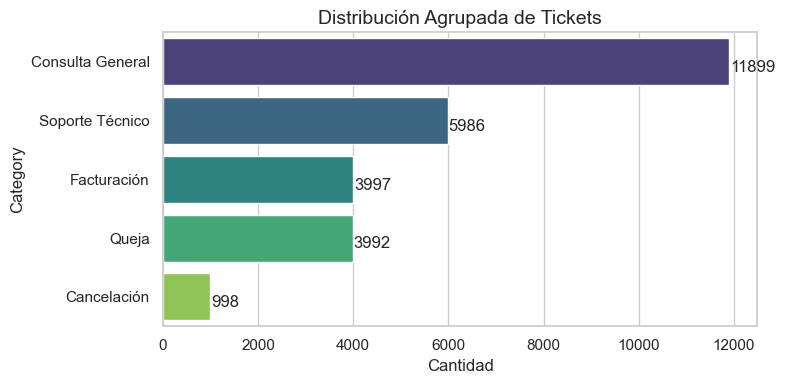

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario para agrupar los intents de Bitext en nuestras 5 categorías
mapeo_bitext = {
    # Soporte Técnico
    'registration_problems': 'Soporte Técnico',
    'edit_account': 'Soporte Técnico',
    'switch_account': 'Soporte Técnico',
    'create_account': 'Soporte Técnico',
    'recover_password': 'Soporte Técnico',
    'delete_account': 'Soporte Técnico',
    
    # Facturación
    'check_invoice': 'Facturación',
    'get_invoice': 'Facturación',
    'payment_issue': 'Facturación',
    'check_payment_methods': 'Facturación',
    
    # Queja
    'complaint': 'Queja',
    'get_refund': 'Queja',
    'track_refund': 'Queja',
    'review': 'Queja',
    
    # Cancelación
    'cancel_order': 'Cancelación',
    
    # Consulta General (Mapeamos algunas explícitas, el resto irán por defecto)
    'contact_customer_service': 'Consulta General',
    'contact_human_agent': 'Consulta General',
    'delivery_period': 'Consulta General',
    'newsletter_subscription': 'Consulta General',
    'place_order': 'Consulta General',
    'change_order': 'Consulta General',
    'check_refund_policy': 'Consulta General',
    'delivery_options': 'Consulta General',
    'check_cancellation_fee': 'Consulta General',
    'track_order': 'Consulta General'
}

# Aplicar el mapeo. Usamos .fillna() para que cualquier intent raro o nuevo caiga en Consulta General.
df_model['Category'] = df_model['Ticket_Type_Original'].map(mapeo_bitext).fillna('Consulta General')

# Verificar que el mapeo fue exitoso
print("=== NUEVA DISTRIBUCIÓN DE MACRO-CATEGORÍAS ===")
conteo = df_model['Category'].value_counts(dropna=False)
print(conteo)

# Crear el dataframe final
df_final = df_model[['Clean_Text', 'Category']].copy()

# --- GRÁFICA DE DISTRIBUCIÓN ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=conteo.values, y=conteo.index, palette='viridis', hue=conteo.index, legend=False)
plt.title('Distribución Agrupada de Tickets', fontsize=14)
plt.xlabel('Cantidad', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width() + 20, p.get_y() + 0.5), va='center')
    
plt.tight_layout()
plt.show()

## 4. Implementación Manual de K-Folds Cross Validation

Como requerimiento técnico, se debe implementar K-Folds de forma manual (sin usar `sklearn.model_selection.KFold`). Se utilizará $K=5$.
El siguiente código mezcla el dataset aleatoriamente y genera una lista de 5 tuplas, donde cada tupla contiene `(DataFrame_Entrenamiento, DataFrame_Prueba)`.

In [15]:
import numpy as np

def generate_k_folds(df, k=5, seed=42):
    # 1. Mezclar el dataframe aleatoriamente (Shuffle)
    # Se usa una semilla (seed) para que los resultados sean reproducibles
    df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # 2. Calcular el tamaño de cada pliegue (fold)
    n_samples = len(df_shuffled)
    fold_size = n_samples // k
    
    folds_data = []
    
    # 3. Iterar k veces para crear los conjuntos de train y test
    for i in range(k):
        # Índices de inicio y fin para el conjunto de prueba en esta iteración
        start_idx = i * fold_size
        # En el último fold, se toman todos los elementos restantes para no perder datos
        end_idx = (i + 1) * fold_size if i < k - 1 else n_samples
        
        # Extraer el conjunto de prueba
        test_fold = df_shuffled.iloc[start_idx:end_idx]
        
        # Extraer el conjunto de entrenamiento (todo lo que no es el test_fold)
        train_fold = pd.concat([df_shuffled.iloc[:start_idx], df_shuffled.iloc[end_idx:]])
        
        folds_data.append((train_fold, test_fold))
        
    return folds_data

# Generar los 5 pliegues
k_folds_splits = generate_k_folds(df_final, k=5)

# Verificar los tamaños de los conjuntos generados
print("=== VERIFICACIÓN DE TAMAÑOS DE K-FOLDS (K=5) ===")
for i, (train, test) in enumerate(k_folds_splits):
    print(f"Fold {i+1} -> Entrenamiento: {len(train)} filas | Prueba: {len(test)} filas")

=== VERIFICACIÓN DE TAMAÑOS DE K-FOLDS (K=5) ===
Fold 1 -> Entrenamiento: 21498 filas | Prueba: 5374 filas
Fold 2 -> Entrenamiento: 21498 filas | Prueba: 5374 filas
Fold 3 -> Entrenamiento: 21498 filas | Prueba: 5374 filas
Fold 4 -> Entrenamiento: 21498 filas | Prueba: 5374 filas
Fold 5 -> Entrenamiento: 21496 filas | Prueba: 5376 filas


## 5. Implementación Manual de Métricas de Evaluación

Para cumplir con la restricción de no utilizar bibliotecas automatizadas para la clasificación y evaluación, se definen las funciones matemáticas desde cero para calcular:
* **Matriz de Confusión**
* **Precisión, Recall y F1-Score (por clase)**
* **Accuracy Global y Macro F1**

In [16]:
def calcular_metricas_manuales(y_true, y_pred, clases):
    # 1. Construir Matriz de Confusión
    cm = {c_true: {c_pred: 0 for c_pred in clases} for c_true in clases}
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
        
    metricas_clase = {}
    total_correctos = 0
    total_instancias = len(y_true)
    
    # 2. Calcular TP, FP, FN y métricas por clase
    for c in clases:
        TP = cm[c][c]
        total_correctos += TP
        
        FP = sum(cm[c_otra][c] for c_otra in clases if c_otra != c)
        FN = sum(cm[c][c_otra] for c_otra in clases if c_otra != c)
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        metricas_clase[c] = {
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }
        
    # 3. Calcular métricas globales
    accuracy = total_correctos / total_instancias if total_instancias > 0 else 0.0
    macro_f1 = sum(m['F1-Score'] for m in metricas_clase.values()) / len(clases)
    
    return {
        'Matriz_Confusion': cm,
        'Metricas_Clase': metricas_clase,
        'Accuracy': accuracy,
        'Macro_F1': macro_f1
    }

print("Funciones de evaluación manual definidas correctamente.")

Funciones de evaluación manual definidas correctamente.


## 6. Entrenamiento y Evaluación K-Folds (Integración del Modelo)

En esta fase se integra la clase `NaiveBayesMultinomial`. El algoritmo requiere listas de tokens, por lo que el texto limpio se separa mediante `.split()` antes de ingresar al modelo.
Se itera sobre los 5 pliegues calculando el rendimiento y promediando los resultados finales.

In [17]:
from naive_bayes import NaiveBayesMultinomial

clases_unicas = ['Soporte Técnico', 'Facturación', 'Consulta General', 'Queja', 'Cancelación']

# Acumuladores para el promedio de los K-Folds
k_accuracy = []
k_macro_f1 = []
k_metricas_clase = {c: {'Precision': [], 'Recall': [], 'F1-Score': []} for c in clases_unicas}

print("=== INICIANDO ENTRENAMIENTO K-FOLDS (K=5) ===")

for i, (train_df, test_df) in enumerate(k_folds_splits):
    print(f"\nProcesando Fold {i+1}...")
    
    # 1. Preparar datos: El modelo espera una lista de listas de palabras (tokens)
    X_train = train_df['Clean_Text'].apply(lambda x: x.split()).tolist()
    y_train = train_df['Category'].tolist()
    
    X_test = test_df['Clean_Text'].apply(lambda x: x.split()).tolist()
    y_test = test_df['Category'].tolist()
    
    # 2. Inicializar y Entrenar
    nb_model = NaiveBayesMultinomial()
    nb_model.train(X_train, y_train)
    
    # 3. Predecir conjunto de prueba
    y_pred = [nb_model.predict(doc) for doc in X_test]
    
    # 4. Calcular métricas de este Fold
    resultados = calcular_metricas_manuales(y_test, y_pred, clases_unicas)
    
    # Acumular resultados globales
    k_accuracy.append(resultados['Accuracy'])
    k_macro_f1.append(resultados['Macro_F1'])
    
    # Acumular resultados por clase
    for c in clases_unicas:
        k_metricas_clase[c]['Precision'].append(resultados['Metricas_Clase'][c]['Precision'])
        k_metricas_clase[c]['Recall'].append(resultados['Metricas_Clase'][c]['Recall'])
        k_metricas_clase[c]['F1-Score'].append(resultados['Metricas_Clase'][c]['F1-Score'])
        
    print(f"Fold {i+1} completado -> Accuracy: {resultados['Accuracy']:.4f} | Macro F1: {resultados['Macro_F1']:.4f}")

# Promedios Finales
print("\n=== RESULTADOS FINALES PROMEDIADOS (K-FOLDS) ===")
print(f"Accuracy Promedio: {sum(k_accuracy)/5:.4f}")
print(f"Macro F1 Promedio: {sum(k_macro_f1)/5:.4f}")

=== INICIANDO ENTRENAMIENTO K-FOLDS (K=5) ===

Procesando Fold 1...
Fold 1 completado -> Accuracy: 0.9918 | Macro F1: 0.9868

Procesando Fold 2...
Fold 2 completado -> Accuracy: 0.9924 | Macro F1: 0.9859

Procesando Fold 3...
Fold 3 completado -> Accuracy: 0.9881 | Macro F1: 0.9805

Procesando Fold 4...
Fold 4 completado -> Accuracy: 0.9900 | Macro F1: 0.9844

Procesando Fold 5...
Fold 5 completado -> Accuracy: 0.9896 | Macro F1: 0.9831

=== RESULTADOS FINALES PROMEDIADOS (K-FOLDS) ===
Accuracy Promedio: 0.9904
Macro F1 Promedio: 0.9841


## 7. Análisis de Métricas por Clase y Matriz de Confusión

A continuación, se extraen los promedios de Precisión, Recall y F1-Score para cada una de las 5 categorías evaluadas en el K-Folds. También se visualiza la Matriz de Confusión del último pliegue para analizar qué clases se están confundiendo entre sí.

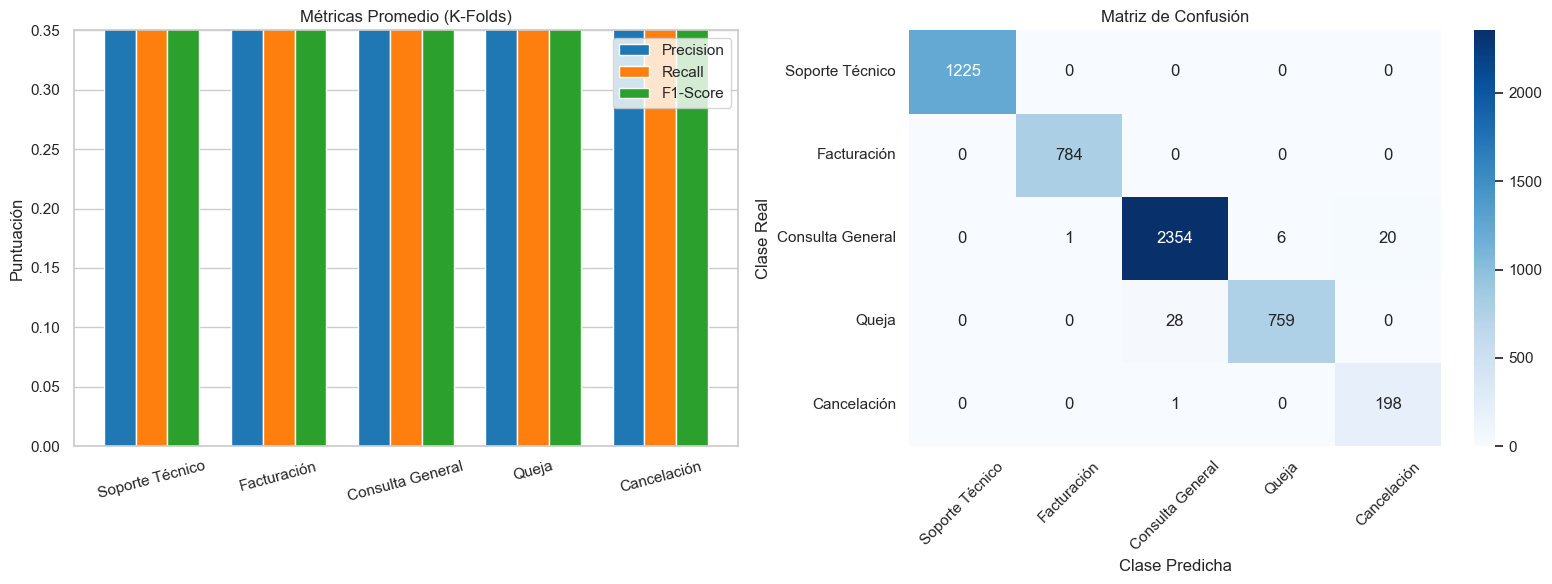

In [18]:
import numpy as np

precisiones = []
recalls = []
f1_scores = []

for c in clases_unicas:
    p_avg = sum(k_metricas_clase[c]['Precision']) / 5
    r_avg = sum(k_metricas_clase[c]['Recall']) / 5
    f1_avg = sum(k_metricas_clase[c]['F1-Score']) / 5
    
    precisiones.append(p_avg)
    recalls.append(r_avg)
    f1_scores.append(f1_avg)

cm = resultados['Matriz_Confusion']
encabezados = "".join([f"{c[:4]:>6}" for c in clases_unicas])
for c_true in clases_unicas:
    fila = "".join([f"{cm[c_true][c_pred]:>6}" for c_pred in clases_unicas])

# --- GRÁFICAS DE MÉTRICAS Y MATRIZ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Barras de Métricas
x = np.arange(len(clases_unicas))
width = 0.25
ax1.bar(x - width, precisiones, width, label='Precision', color='#1f77b4')
ax1.bar(x, recalls, width, label='Recall', color='#ff7f0e')
ax1.bar(x + width, f1_scores, width, label='F1-Score', color='#2ca02c')

ax1.set_ylabel('Puntuación')
ax1.set_title('Métricas Promedio (K-Folds)')
ax1.set_xticks(x)
ax1.set_xticklabels(clases_unicas, rotation=15)
ax1.legend()
ax1.set_ylim(0, 0.35)

# Gráfica 2: Mapa de Calor (Heatmap) Matriz de Confusión
cm_matrix = [[cm[c_true][c_pred] for c_pred in clases_unicas] for c_true in clases_unicas]
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases_unicas, yticklabels=clases_unicas, ax=ax2)
ax2.set_title('Matriz de Confusión')
ax2.set_ylabel('Clase Real')
ax2.set_xlabel('Clase Predicha')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Entrenamiento del Modelo Final y Persistencia

Una vez validadas las métricas y el comportamiento del modelo, se procede a entrenar el motor de inferencia utilizando el 100% del dataset disponible. Finalmente, el objeto del modelo se guarda en un archivo `modelo_final.pkl` para ser consumido por la aplicación web.

In [19]:
print("=== ENTRENANDO MODELO FINAL (100% DE LOS DATOS) ===")

# 1. Preparar todo el dataset
X_total = df_final['Clean_Text'].apply(lambda x: x.split()).tolist()
y_total = df_final['Category'].tolist()

# 2. Inicializar y Entrenar
modelo_final = NaiveBayesMultinomial()
modelo_final.train(X_total, y_total)

nombre_archivo = "modelo_final.pkl"
modelo_final.save(nombre_archivo)

print(f"¡Éxito! El modelo ha sido entrenado con {len(X_total)} tickets.")
print(f"Archivo '{nombre_archivo}' guardado correctamente en la carpeta actual.")

=== ENTRENANDO MODELO FINAL (100% DE LOS DATOS) ===
¡Éxito! El modelo ha sido entrenado con 26872 tickets.
Archivo 'modelo_final.pkl' guardado correctamente en la carpeta actual.
